#Exercise: Hiearchical Models and Testing

**Authors:** Sek Huen Leung, Kadri Kalamäe

**Date:** 22.09.2026

## Introduction
We analyze a dataset from randomized case-control studies investigating the effectiveness of descriptive social norms on hotel guests' towel reuse behavior.

Our objectives are to:
1. Formulate and justify a parametric hierarchical model for testing intervention effectiveness.
2. Estimate model parameters using Bayesian inference.
3. Test whether the social norm intervention has a statistically credible effect on towel reuse.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import gdown
import arviz as az
import bambi as bmb
from IPython.display import display, Markdown
import seaborn as sns

gdown.download(
    id="1k2V8KBIh3Nva7-ip2omOihNby0rXzMHJ",
    output="towelData.csv",
    quiet=True
)

random_seed = 123

In [2]:
# read in data
data_file = "towelData.csv"
data = pd.read_csv(data_file, sep=';', encoding='latin1')

count = data.iloc[:, -1] # get the last column with numbers or yes/no

# count has the number of yes and no for control and social norm groups
control_yes = count[::4].to_numpy() # every 4th starting from 0 - control group + yes
control_no = count[2::4].to_numpy() # every 4th starting from 2 - control group + no
control_total = np.array([y + n for y, n in zip(control_yes, control_no)])

social_yes = count[1::4].to_numpy() # every 4th starting from 1 - social norm group + yes
social_no = count[3::4].to_numpy() # every 4th starting from 3 - social norm group + no
social_total = np.array([y + n for y, n in zip(social_yes, social_no)])

study = np.arange(1,len(control_yes)+1) # 7 diferent studies

control_data = pd.DataFrame({"reuse": control_yes, "total": control_total, "group": "control", "study": study})
social_data = pd.DataFrame({ "reuse": social_yes, "total": social_total, "group": "social", "study": study})

combined_data = pd.concat([control_data, social_data], ignore_index=True)

# Convert data types - important for bambi that they are correctly set
# can give errors otherwise
combined_data['reuse'] = combined_data['reuse'].astype(int)
combined_data['total'] = combined_data['total'].astype(int)
combined_data['group'] = combined_data['group'].astype('category')
combined_data['study'] = combined_data['study'].astype('category')
combined_data['avg'] = combined_data['reuse'] / combined_data['total']
combined_data['study_group'] = (combined_data['study'].astype(str) + '_' + combined_data['group'].astype(str))
combined_data.head()

,reuse,total,group,study,avg,study_group
0,74,211,control,1,0.350711,1_control
1,103,277,control,2,0.371841,2_control
2,77,135,control,3,0.570370,3_control
3,82,187,control,4,0.438503,4_control
4,21,25,control,5,0.840000,5_control


## Exploratory Data Analysis

Before fitting the model, we visualize the reuse counts and total sample sizes for both the control and social norm groups across all studies in order to gain a better understanding of the distribution of the variables and their relationships.

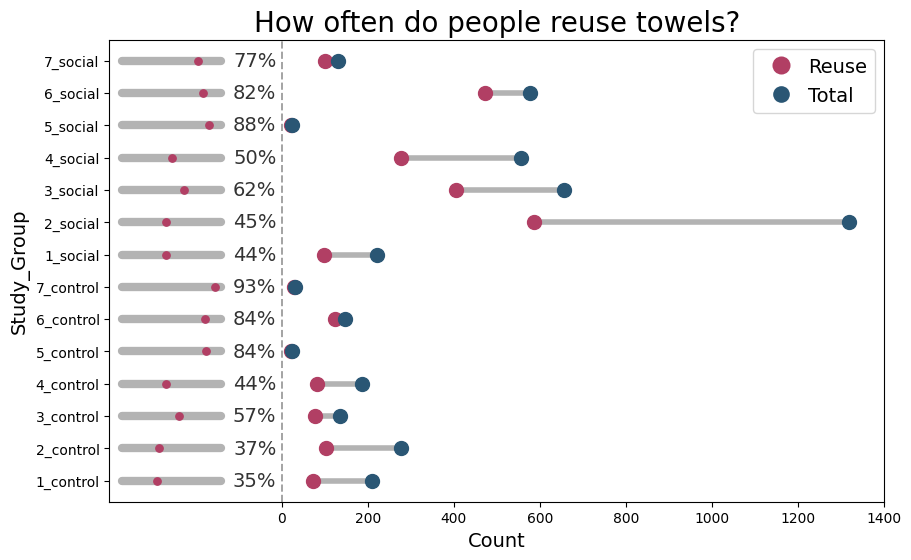

In [3]:
_, ax = plt.subplots(figsize=(10, 6))

BLUE = "#2a5674"
RED = "#b13f64"

# Customize x limits.
# This adds space on the left side to indicate percentage of hits.
ax.set_xlim(-400, 320)

# Add dots for reuse and total
ax.scatter(combined_data["reuse"], list(range(14)), s=100, color=RED, zorder=10)
ax.scatter(combined_data["total"], list(range(14)), s=100, color=BLUE, zorder=10)

# Also a line connecting them
ax.hlines(list(range(14)), combined_data["reuse"], combined_data["total"], color="#b3b3b3", lw=4)

ax.axvline(ls="--", lw=1.4, color="#a3a3a3")
ax.hlines(list(range(14)), -370, -140, lw=6, color="#b3b3b3", capstyle="round")
ax.scatter(230 * combined_data["avg"] - 370, list(range(14)), s=28, color=RED, zorder=10)

# Add the percentage of towel reuse
for j in range(14):
    text = f"{round(combined_data['avg'].iloc[j] * 100)}%"
    ax.text(-12, j, text, ha="right", va="center", fontsize=14, color="#333")

# Customize tick positions and labels
ax.yaxis.set_ticks(list(range(14)))
ax.yaxis.set_ticklabels(combined_data["study_group"])
ax.xaxis.set_ticks(range(0, 1500, 200))

# Create handles for the legend (just dots and labels)
handles = [
    Line2D(
        [0], [0], label="Reuse", marker="o", color="None", markeredgewidth=0,
        markerfacecolor=RED, markersize=13
    ),
    Line2D(
        [0], [0], label="Total", marker="o", color="None", markeredgewidth=0,
        markerfacecolor=BLUE, markersize=12
    )
]

# Add legend on top-right corner
legend = ax.legend(
    handles=handles,
    loc=1,
    fontsize=14,
    handletextpad=0.4,
    frameon=True
)

# Finally add labels and a title
ax.set_xlabel("Count", fontsize=14)
ax.set_ylabel("Study_Group", fontsize=14)
ax.set_title("How often do people reuse towels?", fontsize=20);

The first thing one can see from the figure above is that the sample sizes vary quite a lot across studies. While some studies have a relatively small number of observations, others have multiple hundreds of trials. We can also note that the reuse percentages range broadly, from $35\%$ up to $93\%$. The visible variation in baseline reuse rates and outcomes across the studies in this plot justifies using a hierarchical model, which allows both the baseline reuse rate and the intervention effect to vary randomly across individual studies.

## Hierarchical Model

### Model Formulation

The response variable is the number of guests who reused their towels out of the total number of guests in each treatment group. Since each guest either reused or did not reuse their towel, and the observations are available as the number of successful outcomes out of a known total, a binomial distribution is appropriate.

Let $Y_{ij}$ denote the number of guests who reused their towels in group $j$ of study $i$, and let $n_{ij}$ denote the total number of guests in that group. We assume

$$
Y_{ij} \mid p_{ij}
\sim
\operatorname{Binomial}(n_{ij},p_{ij}),
$$

where $p_{ij}$ is the probability of towel reuse.

A logit link is used to relate the reuse probability to the treatment group. The hierarchical model is

$$
\operatorname{logit}(p_{ij})
=
\log\left(\frac{p_{ij}}{1-p_{ij}}\right)
=
\alpha + u_i + (\beta + v_i)x_{ij},
$$

where

$$
x_{ij}
=
\begin{cases}
0, & \text{control group},\\
1, & \text{social-norm group}.
\end{cases}
$$

Here, $\alpha$ represents the overall baseline log-odds of towel reuse in the control group, while $\beta$ represents the overall effect of the social-norm intervention on the log-odds of towel reuse.

The term $u_i$ is a study-specific deviation from the overall intercept. It allows the baseline probability of towel reuse to differ between studies. The term $v_i$ is a study-specific deviation from the overall intervention effect. Therefore, the intervention effect in study $i$ is

$$
\beta_i = \beta + v_i.
$$

The study-specific effects are modelled hierarchically as

$$
u_i \mid \sigma_{\alpha}
\sim
\mathcal{N}(0,\sigma_{\alpha}^2),
$$

and

$$
v_i \mid \sigma_{\beta}
\sim
\mathcal{N}(0,\sigma_{\beta}^2).
$$

The parameter $\sigma_{\alpha}$ describes the between-study heterogeneity in the baseline towel-reuse rate, whereas $\sigma_{\beta}$ describes the between-study heterogeneity in the effect of the social-norm intervention.

For the control group, where $x_{ij}=0$, the model becomes

$$
\operatorname{logit}(p_{i,\mathrm{control}})
=
\alpha + u_i.
$$

For the social-norm group, where $x_{ij}=1$, it becomes

$$
\operatorname{logit}(p_{i,\mathrm{social}})
=
\alpha + u_i + \beta + v_i.
$$

Hence, within study $i$, the difference in log-odds between the social-norm and control groups is

$$
\operatorname{logit}(p_{i,\mathrm{social}})
-
\operatorname{logit}(p_{i,\mathrm{control}})
=
\beta + v_i
=
\beta_i.
$$

Thus, unlike a model with only a study-specific intercept, this model allows the effect of the social-norm intervention itself to vary between studies.

On the odds scale, the overall intervention effect is

$$
\exp(\beta),
$$

which can be interpreted as the overall odds ratio comparing the social-norm group with the control group. For study $i$, the corresponding study-specific odds ratio is

$$
\exp(\beta + v_i).
$$

### Model Implementation

First, we use Bambi's default weakly informative priors for the model parameters.

In [4]:
model_hierarchical = bmb.Model("p(reuse, total) ~ 1 + group + (1 + group | study)", combined_data, family="binomial")
model_hierarchical

       Formula: p(reuse, total) ~ 1 + group + (1 + group | study)
        Family: binomial
          Link: p = logit
  Observations: 14
        Priors: 
    target = p
        Common-level effects
            Intercept ~ Normal(mu: 0.0, sigma: 1.5)
            group ~ Normal(mu: 0.0, sigma: 1.0)
        
        Group-level effects
            1|study ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 2.5495))
            group|study ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 5.0))

### Model Fitting and Sampling

Now we fit the hierarchical model using MCMC sampling with default configuration settings.

In [5]:
idata_hierarchical = model_hierarchical.fit(random_seed = random_seed)

Output()

ERROR:pymc.stats.convergence:There were 9 divergences after tuning. Increase `target_accept` or reparameterize.


The first sampling run reported 9 divergent transitions after tuning. The standard fix is to increase `target_accept` and the number of draws, which we do below.

In [6]:
idata_hierarchical = model_hierarchical.fit(
    draws=2000,
    target_accept=0.95,
    random_seed=random_seed
)

Output()

ERROR:pymc.stats.convergence:There were 6 divergences after tuning. Increase `target_accept` or reparameterize.


Although this improved performance, 6 divergences still occurred. One thing we could try is increasing `target_accept` or `tune` parameter. But divergences might also suggest a problem with the underlying model. Let's take a look at the prior predictive distribution to see whether our priors are too informative or too wide.

In [7]:
idata_prior = model_hierarchical.prior_predictive(random_seed=random_seed)
prior = idata_prior.prior_predictive["p(reuse, total)"]

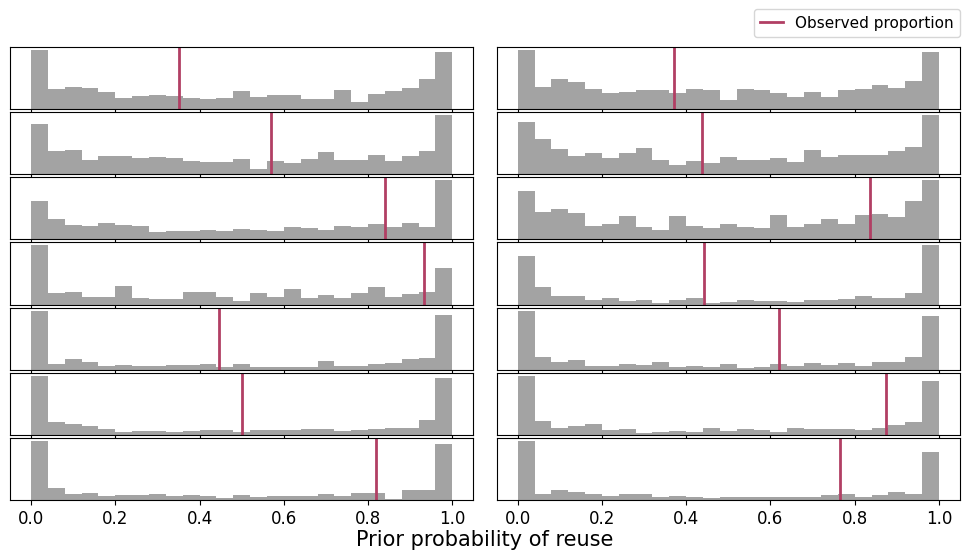

In [8]:
# We define this function because this plot is going to be repeated below.
def plot_prior_predictive(df, prior):
    total = df["total"].values
    reuse = df["reuse"].values

    fig, axes = plt.subplots(7, 2, figsize=(10, 6), sharex="col")

    for idx, ax in enumerate(axes.ravel()):
        pps = prior.sel({"__obs__":idx})
        t = total[idx]
        r = reuse[idx]

        # Flatten the multi-chain/draw data into a 1D array for the histogram
        hist_data = (pps/t).values.flatten()

        hist = ax.hist(hist_data, bins=25, color="#a3a3a3")
        ax.axvline(r / t, color=RED, lw=2)
        ax.set_yticks([])
        ax.tick_params(labelsize=12)

    fig.subplots_adjust(left=0.025, right=0.975, hspace=0.05, wspace=0.05, bottom=0.125)
    fig.legend(
        handles=[Line2D([0], [0], label="Observed proportion", color=RED, linewidth=2)],
        handlelength=1.5,
        handletextpad=0.8,
        borderaxespad=0,
        frameon=True,
        fontsize=11,
        bbox_to_anchor=(0.975, 0.92),
        loc="right"

    )
    fig.text(0.5, 0.05, "Prior probability of reuse", fontsize=15, ha="center", va="baseline")

plot_prior_predictive(combined_data, prior)

Bambi's automatically generated default priors (`Intercept ~ Normal(0, 1.5)`, `group ~ Normal(0, 1.0)`, group-level SDs `~ HalfNormal(2.5)` / `HalfNormal(5.0)`) are very wide. This motivates tightening the priors below.

### Choosing better priors

Using one common weakly-informative scale across all four is a standard simplification, so we explored a range of common values. We use $\sigma = 1$ for all four priors below.

In [9]:
priors = {
    "Intercept": bmb.Prior("Normal", mu=0, sigma=1),
    "group": bmb.Prior("Normal", mu=0, sigma=1),
    "1|study": bmb.Prior("Normal", mu=0, sigma=bmb.Prior("HalfNormal", sigma=1)),
    "group|study": bmb.Prior("Normal", mu=0, sigma=bmb.Prior("HalfNormal", sigma=1)),
}
model_hierarchical_2 = bmb.Model("p(reuse, total) ~ 1 + group + (1 + group | study)", combined_data, family="binomial", priors=priors)
model_hierarchical_2

       Formula: p(reuse, total) ~ 1 + group + (1 + group | study)
        Family: binomial
          Link: p = logit
  Observations: 14
        Priors: 
    target = p
        Common-level effects
            Intercept ~ Normal(mu: 0.0, sigma: 1.0)
            group ~ Normal(mu: 0.0, sigma: 1.0)
        
        Group-level effects
            1|study ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 1.0))
            group|study ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 1.0))

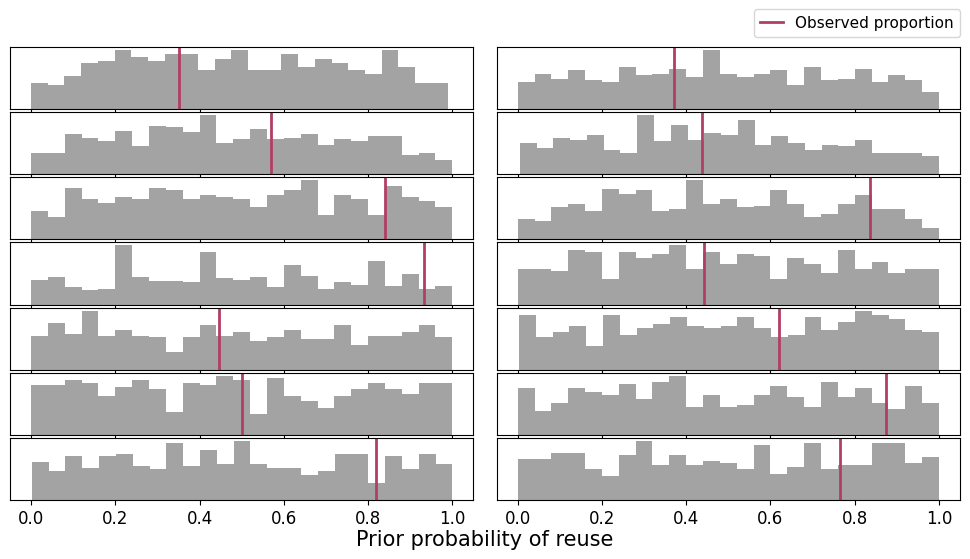

In [10]:
model_hierarchical_2.build()
idata_prior_2 = model_hierarchical_2.prior_predictive()
prior_2 = idata_prior_2.prior_predictive["p(reuse, total)"]
plot_prior_predictive(combined_data, prior_2)

With the tighter priors ($\sigma = 1$), the prior predictive distribution is improved. The pile-ups at $0$ and $1$ have disappeared, and the prior probabilities of reuse are now smoothly distributed across a plausible range. Also, the red vertical lines representing the observed proportions fall relatively well within the core of the prior distributions.

With our new tighter priors in place, we now fit the hierarchical model again.

In [11]:
idata_hierarchical_2 = model_hierarchical_2.fit(random_seed=random_seed)

Output()

ERROR:pymc.stats.convergence:There were 3 divergences after tuning. Increase `target_accept` or reparameterize.


Although the initial fit with tighter priors improved stability (reducing divergences to 3), we increase `target_accept` to $0.95$ and use $2,000$ draws to completely eliminate remaining divergent transitions and ensure reliable convergence.

In [12]:
idata_hierarchical_2 = model_hierarchical_2.fit(
    draws=2000,
    target_accept=0.95,
    random_seed=random_seed
)

Output()

To check for convergence and mixing across the model parameters, we generate trace plots for the main population-level terms, the study-specific baseline intercepts, and the study-specific intervention effects.

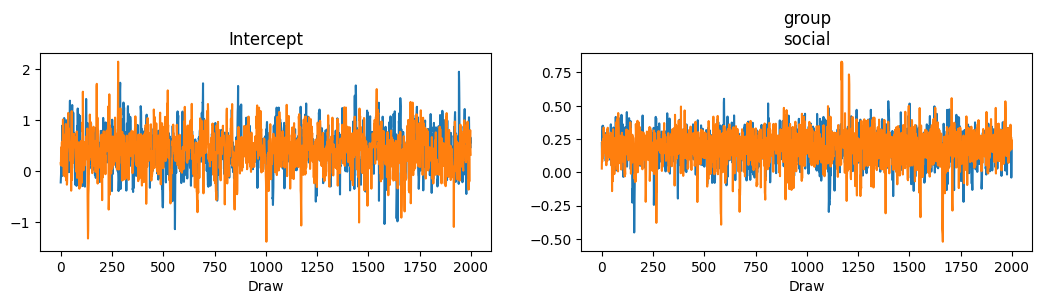

In [13]:
az.plot_trace(idata_hierarchical_2, var_names=["Intercept", "group"])

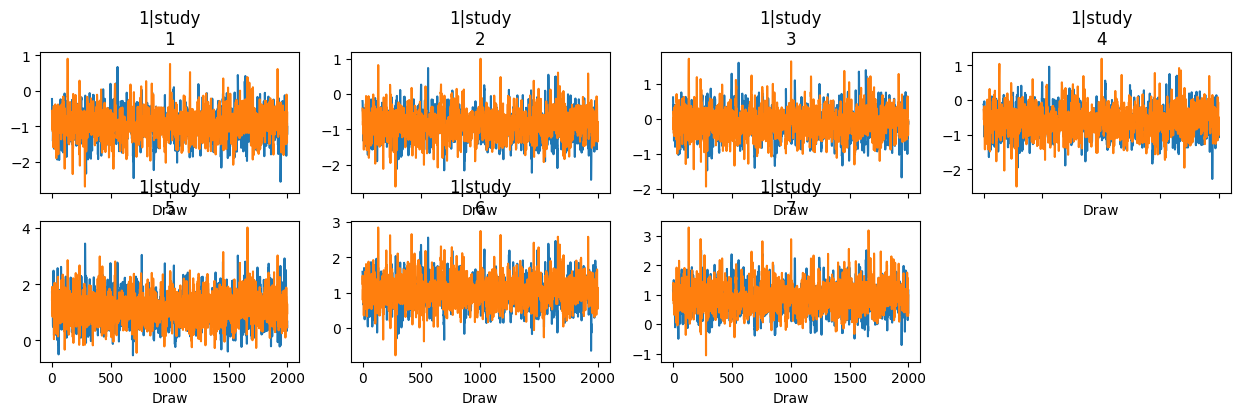

In [14]:
az.plot_trace(idata_hierarchical_2, var_names=["1|study"])

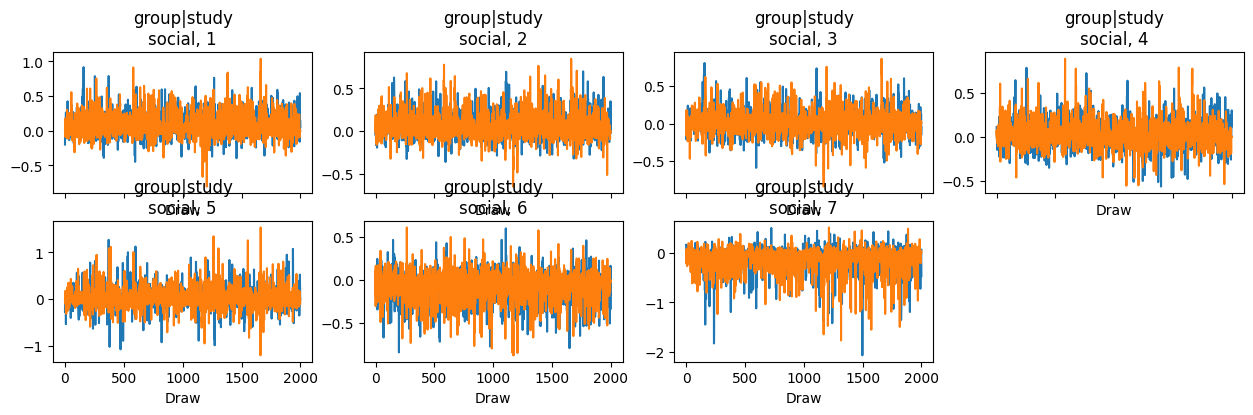

In [15]:
az.plot_trace(idata_hierarchical_2, var_names=["group|study"])

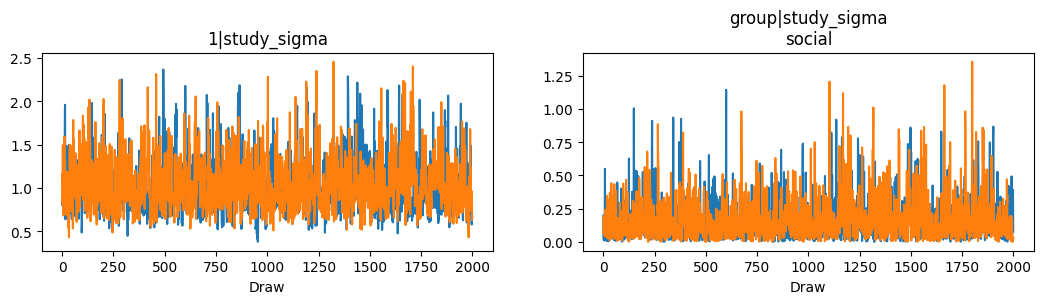

In [16]:
az.plot_trace(idata_hierarchical_2, var_names=["1|study_sigma", "group|study_sigma"])

Across all trace plots, including the population-level effects, between-study standard deviations (`1|study_sigma` and `group|study_sigma`), study-specific intercepts (`1|study`), and study-specific intervention effects (`group|study`), the chains show healthy mixing and stationarity with no signs of divergence. This confirms that the MCMC sampling for our updated model is reliable.

### Summary of Parameter Values by the Posterior Mean and 90% Probability Interval

To summarize the posterior distributions, we report the posterior mean and the 90% probability interval for each parameter. The table below presents the population-level parameters along with the study-specific intercepts ($u_i$) and slope deviations ($v_i$).

In [17]:
summary_hierarchical = az.summary(
    idata_hierarchical_2,
    ci_prob=0.90
)

summary_table = summary_hierarchical[
    ["mean", "eti90_lb", "eti90_ub"]
].copy()


summary_table.columns = [
    "Posterior mean",
    "90% PI lower",
    "90% PI upper"
]

parameter_names = {
    "Intercept": r"$\alpha$",
    "group[social]": r"$\beta$",
    "1|study_sigma": r"$\sigma_\alpha$",
    "group|study_sigma[social]": r"$\sigma_\beta$"
}

# Study-specific intercepts and slopes
for i in range(1, 8):
    parameter_names[f"1|study[{i}]"] = rf"$u_{i}$"
    parameter_names[f"group|study[social, {i}]"] = rf"$v_{i}$"

summary_table = summary_table.rename(index=parameter_names)
summary_table = summary_table.round(3)
summary_table.index.name = "Parameter"
display(Markdown(summary_table.to_markdown()))

| Parameter       |   Posterior mean |   90% PI lower |   90% PI upper |
|:----------------|-----------------:|---------------:|---------------:|
| $\alpha$        |            0.405 |         -0.207 |          1.026 |
| $\beta$         |            0.184 |         -0.014 |          0.359 |
| $\sigma_\alpha$ |            1.027 |          0.639 |          1.609 |
| $\sigma_\beta$  |            0.159 |          0.01  |          0.448 |
| $u_1$           |           -0.94  |         -1.576 |         -0.292 |
| $u_2$           |           -0.87  |         -1.478 |         -0.242 |
| $u_3$           |           -0.111 |         -0.727 |          0.524 |
| $u_4$           |           -0.616 |         -1.243 |          0.024 |
| $u_5$           |            1.134 |          0.338 |          2.027 |
| $u_6$           |            1.029 |          0.404 |          1.687 |
| $u_7$           |            0.881 |          0.173 |          1.665 |
| $v_1$           |            0.064 |         -0.121 |          0.361 |
| $v_2$           |            0.055 |         -0.112 |          0.303 |
| $v_3$           |            0.012 |         -0.196 |          0.247 |
| $v_4$           |            0.024 |         -0.171 |          0.259 |
| $v_5$           |            0.026 |         -0.249 |          0.363 |
| $v_6$           |           -0.063 |         -0.356 |          0.134 |
| $v_7$           |           -0.115 |         -0.557 |          0.106 |

## Formulating and Testing Hypotheses for the Effectiveness of the Intervention

We test two related hypotheses about the intervention.

- **Effectiveness of the intervention:** $H_0: \beta \le 0$ (the social-norm message does not increase towel reuse) vs. $H_1: \beta > 0$ (it increases reuse). We can evaluate the posterior probability $P(\beta > 0 \mid \text{data})$ and report the 90% probability interval as a summary of the effect size.
- **Consistency of the effect across studies:** $H_0: \sigma_\beta = 0$ (the intervention effect is identical in every study) vs. $H_1: \sigma_\beta > 0$ (the effect size varies between studies).

In [19]:
beta_samples = idata_hierarchical_2.posterior["group"].values.flatten()

pi_90 = az.eti(beta_samples, prob=0.90)
p_positive = np.mean(beta_samples > 0)
odds_ratio = np.exp(beta_samples)

print(f"Posterior mean of beta (log-odds ratio): {beta_samples.mean():.3f}")
print(f"90% credible interval for beta: [{pi_90[0]:.3f}, {pi_90[1]:.3f}]")
print(f"P(beta > 0 | data) = {p_positive:.4f}")
print(f"Posterior mean odds ratio exp(beta): {odds_ratio.mean():.3f}")
print(f"90% CI for odds ratio: [{np.exp(pi_90[0]):.3f}, {np.exp(pi_90[1]):.3f}]")

Posterior mean of beta (log-odds ratio): 0.184
90% credible interval for beta: [-0.014, 0.359]
P(beta > 0 | data) = 0.9403
Posterior mean odds ratio exp(beta): 1.210
90% CI for odds ratio: [0.987, 1.432]


The posterior mean of $\beta$ is $0.184$ (posterior mean odds ratio $\approx 1.21$) with a 90% probability interval of $[-0.014, 0.359]$. The posterior probability of a positive effect is $P(\beta > 0 \mid \text{data}) \approx 0.94$. The interval only marginally includes zero, which is consistent with this probability being just below $0.95$. The data therefore suggest a small positive effect of the social-norm message, but the evidence is not conclusive.

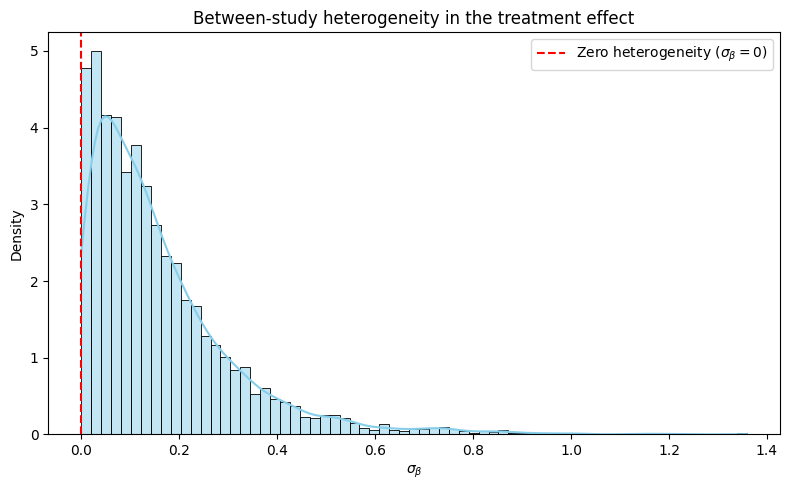

In [20]:
sigma_samples = idata_hierarchical_2.posterior["group|study_sigma"].values.flatten()

plt.figure(figsize=(8, 5))
sns.histplot(sigma_samples, kde=True, stat="density", color="skyblue", edgecolor="black")
plt.title("Between-study heterogeneity in the treatment effect")
plt.xlabel(r"$\sigma_\beta$")
plt.ylabel("Density")
plt.axvline(0, color="red", linestyle="--", label=r"Zero heterogeneity ($\sigma_\beta = 0$)")
plt.legend()
plt.tight_layout()
plt.show()

The posterior of $\sigma_\beta$ is strongly right-skewed and concentrated close to zero: the density is highest at small values and decreases steadily, with a posterior mean of $0.159$ and a 90% probability interval of $[0.01, 0.448]$. This means the data are consistent with the intervention effect being similar across the seven studies, which agrees with the small study-specific deviations $v_i$ (posterior means within $\pm 0.12$, all intervals covering zero). However, the posterior is not concentrated exactly at zero. Its right tail reaches about $0.45$ so moderate heterogeneity cannot be ruled out. This is unsurprising with only seven studies, several of them small. Since $\sigma_\beta \ge 0$, the red line marks the boundary of the parameter space, and a posterior piled up near it indicates little heterogeneity rather than a formal test of $\sigma_\beta = 0$. We conclude that there is no clear evidence of between-study heterogeneity in the intervention effect.

## Conclusion

We fitted a Bayesian hierarchical binomial model (logit link) with study-specific intercepts and study-specific intervention effects to seven randomised towel-reuse studies. The average control-group reuse rate was about 60% ($\alpha = 0.405$, 90% PI $[-0.207, 1.026]$ on the log-odds scale), and baseline reuse varied substantially between studies ($\sigma_\alpha \approx 1.03$). The social-norm message increased the odds of towel reuse by an estimated factor of 1.21 (posterior mean $\beta = 0.184$, 90% PI $[-0.014, 0.359]$), which corresponds to roughly 4 percentage points from a 60% baseline. The posterior probability of a positive effect is $0.94$: the evidence is fairly strong but not conclusive, as the 90% interval marginally includes zero. Between-study variation in the intervention effect was small ($\sigma_\beta$ posterior mean $0.16$, 90% PI $[0.01, 0.45]$), so the effect appears broadly consistent across studies, although moderate heterogeneity cannot be excluded with only seven studies. Overall, the data suggest a small positive effect of descriptive social norms on towel reuse.